In [ ]:
"""
DziriBERT Multi-Label Text Classification - Sentiment Analysis Model
=====================================================================
This notebook implements multi-label classification for Algerian dialect
social media comments using DziriBERT fine-tuned for sentiment analysis.

Author: NLP Expert
Dataset: Restaurant reviews in Algerian dialect
Labels: 25 multi-label targets (food, service, place, delivery, price, treatment × sentiment)
"""

# ============================================================================
# 1. SETUP & INSTALLATION
# ============================================================================

!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    hamming_loss,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    multilabel_confusion_matrix
)
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW # Corrected import for AdamW
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Détection du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [ ]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================

# Upload your CSV file in Colab
df = pd.read_csv("/content/multilabel_data_part_1&2.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (12394, 32)

First few rows:


,final_id,comment_text,comment_id,platform,source_name,date,likesCount,food_appreciation,food_complaint,food_recommendation,...,delivery_inquiry,price_appreciation,price_complaint,price_recommendation,price_inquiry,treatment_appreciation,treatment_complaint,treatment_recommendation,treatment_inquiry,out_of_scope
0,818529.0,Dans l'ensemble il est bien le seul hic c'est ...,8479.0,Google Maps,American Burger Factory,2023-08-14T18:57:55.063Z,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,949602.0,"Viande pas bonne , dure , élastique",2856.0,Google Maps,HichamCook Grill House,2022-11-13T23:11:21.981Z,2.0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,556392.0,جاية تحلى الله يبارك,13696.0,Facebook,Restaurant San Benito,2025-12-28T21:02:05.000Z,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,294249.0,Première fois dans ce restaurant . L'accueil e...,6183.0,Google Maps,Casbah Istanbul,2022-10-21T21:25:45.744Z,11.0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,687466.0,صراحة روووعه ونظافه احسن واحد في عنابة صح يطول...,55232.0,tiktok,@askim_food,2026-01-02T21:13:24.963577,3.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



EXPLORATORY DATA ANALYSIS

Total samples: 12394
Total labels: 25

Missing values in comment_text: 0
Samples after removing NaN: 12394

Text Statistics:
Average length: 73.30 characters
Average words: 13.04
Max length: 2194 characters
Min length: 2 characters

Sentiment Type Distribution:
Appreciation: 8409 (67.85%)
Complaint: 4469 (36.06%)
Recommendation: 414 (3.34%)
Inquiry: 1736 (14.01%)

Category Distribution:
Food: 4435 (35.78%)
Service: 1578 (12.73%)
Place: 3994 (32.23%)
Delivery: 552 (4.45%)
Price: 2398 (19.35%)
Treatment: 2071 (16.71%)

Label                          Count      Percentage
--------------------------------------------------
food_appreciation              2712       21.88%
food_complaint                 1421       11.47%
food_recommendation            136        1.10%
food_inquiry                   166        1.34%
service_appreciation           1110       8.96%
service_complaint              437        3.53%
service_recommendation         30         0.24%
service

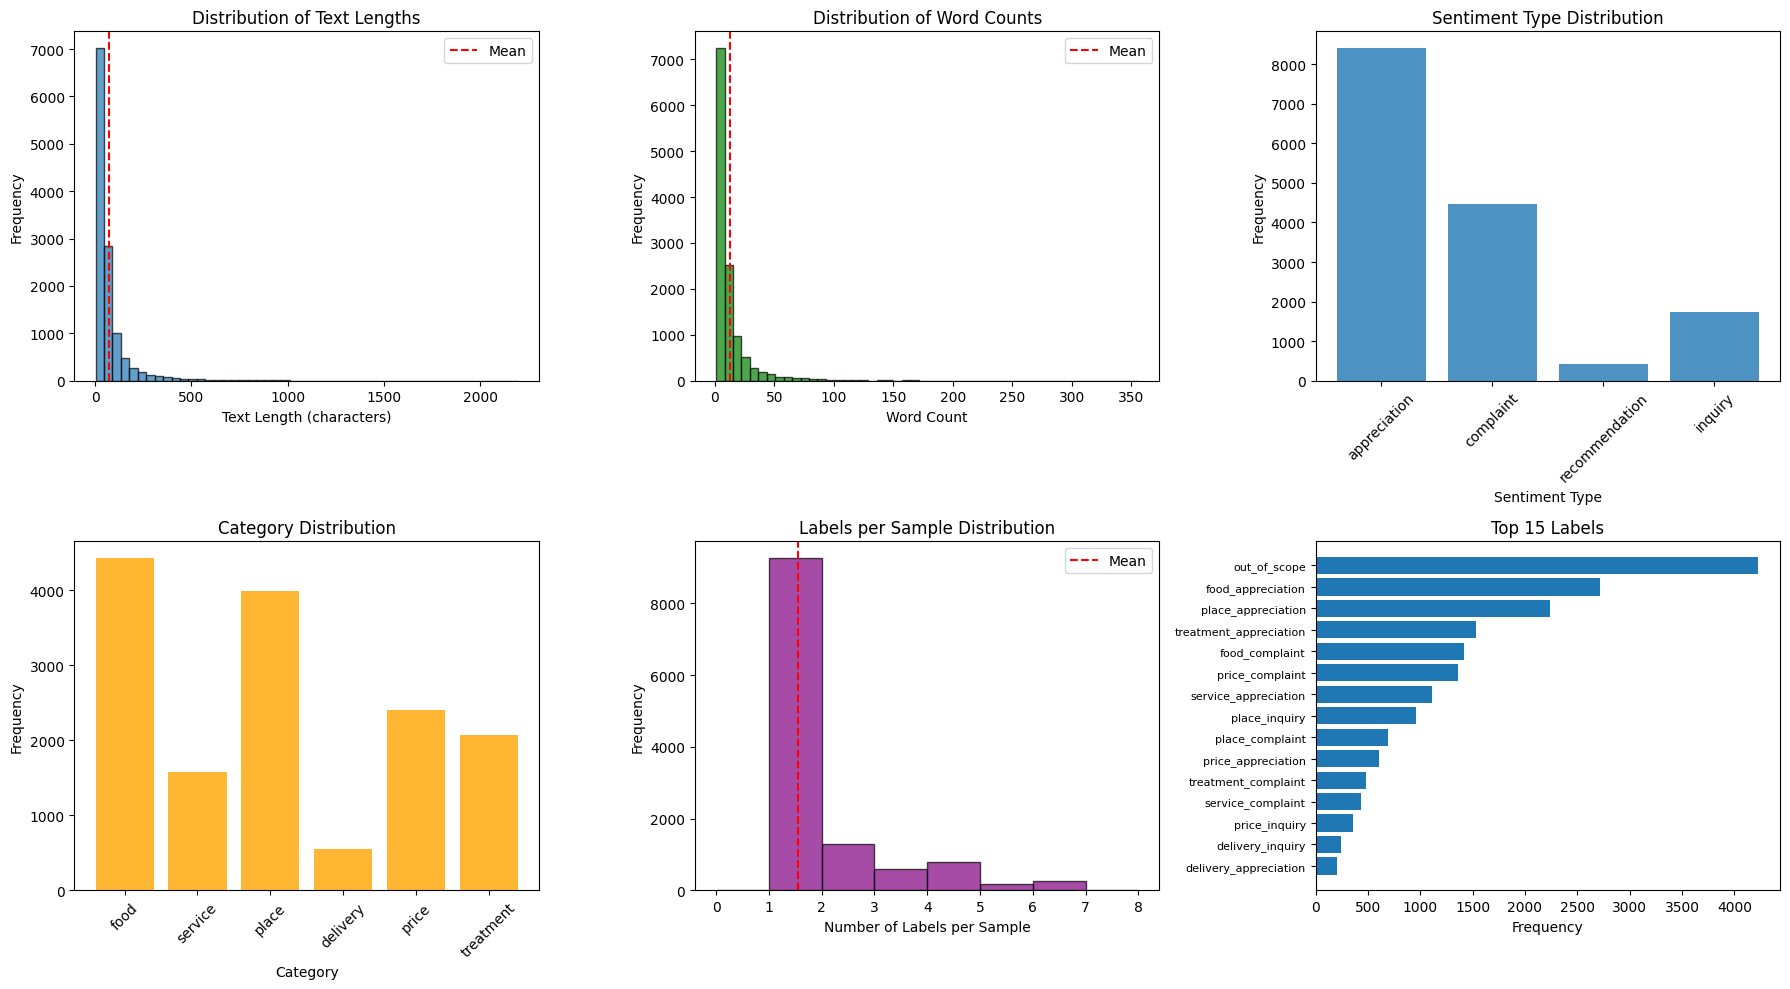


Label Statistics:
Samples with 0 labels: 0
Samples with 1 label: 9273
Samples with 2+ labels: 3121
Average labels per sample: 1.55
Max labels per sample: 7


In [ ]:

# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Define label columns
label_columns = [
    'food_appreciation', 'food_complaint', 'food_recommendation', 'food_inquiry',
    'service_appreciation', 'service_complaint', 'service_recommendation', 'service_inquiry',
    'place_appreciation', 'place_complaint', 'place_recommendation', 'place_inquiry',
    'delivery_appreciation', 'delivery_complaint', 'delivery_recommendation', 'delivery_inquiry',
    'price_appreciation', 'price_complaint', 'price_recommendation', 'price_inquiry',
    'treatment_appreciation', 'treatment_complaint', 'treatment_recommendation', 'treatment_inquiry',
    'out_of_scope'
]

# Basic statistics
print(f"\nTotal samples: {len(df)}")
print(f"Total labels: {len(label_columns)}")
print(f"\nMissing values in comment_text: {df['comment_text'].isna().sum()}")

# Remove rows with missing text
df = df.dropna(subset=['comment_text'])
df = df.reset_index(drop=True)
print(f"Samples after removing NaN: {len(df)}")

# Text length analysis
df['text_length'] = df['comment_text'].str.len()
df['word_count'] = df['comment_text'].str.split().str.len()

print(f"\nText Statistics:")
print(f"Average length: {df['text_length'].mean():.2f} characters")
print(f"Average words: {df['word_count'].mean():.2f}")
print(f"Max length: {df['text_length'].max()} characters")
print(f"Min length: {df['text_length'].min()} characters")

# Sentiment analysis - aggregate sentiment types
sentiment_types = ['appreciation', 'complaint', 'recommendation', 'inquiry']
sentiment_counts = {}

for sent_type in sentiment_types:
    cols = [col for col in label_columns if sent_type in col]
    sentiment_counts[sent_type] = df[cols].sum().sum()

print(f"\nSentiment Type Distribution:")
for sent_type, count in sentiment_counts.items():
    print(f"{sent_type.capitalize()}: {count} ({count/len(df)*100:.2f}%)")

# Category analysis
categories = ['food', 'service', 'place', 'delivery', 'price', 'treatment']
category_counts = {}

for cat in categories:
    cols = [col for col in label_columns if col.startswith(cat)]
    category_counts[cat] = df[cols].sum().sum()

print(f"\nCategory Distribution:")
for cat, count in category_counts.items():
    print(f"{cat.capitalize()}: {count} ({count/len(df)*100:.2f}%)")

# Label distribution
print(f"\n{'Label':<30} {'Count':<10} {'Percentage':<10}")
print("-" * 50)
for label in label_columns:
    count = df[label].sum()
    pct = (count / len(df)) * 100
    print(f"{label:<30} {count:<10} {pct:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Text length distribution
axes[0, 0].hist(df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Text Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Text Lengths')
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Word Counts')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Sentiment type distribution
axes[0, 2].bar(sentiment_counts.keys(), sentiment_counts.values(), alpha=0.8)
axes[0, 2].set_xlabel('Sentiment Type')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Sentiment Type Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)

# Category distribution
axes[1, 0].bar(category_counts.keys(), category_counts.values(), alpha=0.8, color='orange')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Category Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Labels per sample
labels_per_sample = df[label_columns].sum(axis=1)
axes[1, 1].hist(labels_per_sample, bins=range(labels_per_sample.max() + 2),
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Number of Labels per Sample')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Labels per Sample Distribution')
axes[1, 1].axvline(labels_per_sample.mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].legend()

# Top 15 labels
label_counts = df[label_columns].sum().sort_values(ascending=False).head(15)
axes[1, 2].barh(range(len(label_counts)), label_counts.values)
axes[1, 2].set_yticks(range(len(label_counts)))
axes[1, 2].set_yticklabels(label_counts.index, fontsize=8)
axes[1, 2].set_xlabel('Frequency')
axes[1, 2].set_title('Top 15 Labels')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nLabel Statistics:")
print(f"Samples with 0 labels: {(labels_per_sample == 0).sum()}")
print(f"Samples with 1 label: {(labels_per_sample == 1).sum()}")
print(f"Samples with 2+ labels: {(labels_per_sample >= 2).sum()}")
print(f"Average labels per sample: {labels_per_sample.mean():.2f}")
print(f"Max labels per sample: {labels_per_sample.max()}")



In [ ]:
# ============================================================================
# 4. DATA PREPARATION
# ============================================================================
SEED = 42
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Prepare features and labels
X = df['comment_text'].values
y = df[label_columns].values.astype(np.float32)

# Train-validation-test split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=None
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")



DATA PREPARATION
Training samples: 8675
Validation samples: 1859
Test samples: 1860


In [ ]:

# ============================================================================
# 5. TOKENIZATION
# ============================================================================

print("\n" + "="*80)
print("TOKENIZATION")
print("="*80)

# Load DziriBERT Sentiment tokenizer
MODEL_NAME = "alger-ia/dziribert_sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer: {MODEL_NAME}")
print("This model is pre-trained for sentiment analysis on Algerian dialect")

# Tokenization parameters
MAX_LENGTH = 128
BATCH_SIZE = 16

# Custom Dataset class
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float32)
        }

# Create datasets
train_dataset = MultiLabelDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = MultiLabelDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = MultiLabelDataset(X_test, y_test, tokenizer, MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")



TOKENIZATION


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/810 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loaded tokenizer: alger-ia/dziribert_sentiment
This model is pre-trained for sentiment analysis on Algerian dialect
Training batches: 543
Validation batches: 117
Test batches: 117


In [ ]:
from transformers import AutoModel

# ============================================================================
# 6. MODEL DEFINITION
# ============================================================================

print("\n" + "="*80)
print("MODEL DEFINITION")
print("="*80)

class DziriBERTSentimentMultiLabel(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        # Load the sentiment model as base
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use CLS token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits




MODEL DEFINITION


In [ ]:
# ============================================================================
# 7. TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, optimizer, scheduler, device, criterion):
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.sigmoid(logits).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

    return total_loss / len(dataloader), predictions, true_labels

def calculate_metrics(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred >= threshold).astype(int)

    metrics = {
        'hamming_loss': hamming_loss(y_true, y_pred_binary),
        'accuracy': accuracy_score(y_true, y_pred_binary),
        'macro_f1': f1_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'micro_f1': f1_score(y_true, y_pred_binary, average='micro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred_binary, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred_binary, average='macro', zero_division=0)
    }

    return metrics, y_pred_binary

# Initialize model
num_labels = len(label_columns)
model_frozen = DziriBERTSentimentMultiLabel(MODEL_NAME, num_labels).to(device)
print(model_frozen)


DziriBERTSentimentMultiLabel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [ ]:

# ============================================================================
# 8. TRAINING - FROZEN BERT
# ============================================================================

print("\n" + "="*80)
print("TRAINING WITH FROZEN SENTIMENT MODEL (Classifier Only)")
print("="*80)

# Initialize model
num_labels = len(label_columns)
model_frozen = DziriBERTSentimentMultiLabel(MODEL_NAME, num_labels).to(device)

# Freeze BERT parameters
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_frozen.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

# Training configuration
EPOCHS_FROZEN = 5
LEARNING_RATE = 2e-3

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=LEARNING_RATE
)

total_steps = len(train_loader) * EPOCHS_FROZEN
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Training loop
train_losses_frozen = []
val_losses_frozen = []
best_val_f1_frozen = 0
best_model_frozen = None

print("\nStarting training (frozen sentiment model)...")
for epoch in range(EPOCHS_FROZEN):
    print(f"\nEpoch {epoch + 1}/{EPOCHS_FROZEN}")

    train_loss = train_epoch(model_frozen, train_loader, optimizer, scheduler, device, criterion)
    val_loss, val_preds, val_true = evaluate(model_frozen, val_loader, device, criterion)

    metrics, _ = calculate_metrics(val_true, val_preds)

    train_losses_frozen.append(train_loss)
    val_losses_frozen.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {metrics['accuracy']:.4f}")
    print(f"Val Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Val Micro F1: {metrics['micro_f1']:.4f}")
    print(f"Val Hamming Loss: {metrics['hamming_loss']:.4f}")

    if metrics['macro_f1'] > best_val_f1_frozen:
        best_val_f1_frozen = metrics['macro_f1']
        best_model_frozen = model_frozen.state_dict().copy()
        print("✓ New best model saved!")

# Load best model and evaluate on test set
model_frozen.load_state_dict(best_model_frozen)
test_loss_frozen, test_preds_frozen, test_true = evaluate(model_frozen, test_loader, device, criterion)
test_metrics_frozen, test_preds_binary_frozen = calculate_metrics(test_true, test_preds_frozen)

print("\n" + "="*80)
print("FROZEN SENTIMENT MODEL - TEST SET RESULTS")
print("="*80)
for metric, value in test_metrics_frozen.items():
    print(f"{metric}: {value:.4f}")




TRAINING WITH FROZEN SENTIMENT MODEL (Classifier Only)
Trainable parameters: 19,225 / 124,460,569

Starting training (frozen sentiment model)...

Epoch 1/5


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  7.98it/s]


Train Loss: 0.1931
Val Loss: 0.1246
Val Accuracy: 0.3432
Val Macro F1: 0.2305
Val Micro F1: 0.5394
Val Hamming Loss: 0.0472
✓ New best model saved!

Epoch 2/5


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  7.87it/s]


Train Loss: 0.1301
Val Loss: 0.1210
Val Accuracy: 0.3696
Val Macro F1: 0.2405
Val Micro F1: 0.5670
Val Hamming Loss: 0.0449
✓ New best model saved!

Epoch 3/5


...

Train Loss: 0.1231
Val Loss: 0.1159
Val Accuracy: 0.3803
Val Macro F1: 0.2645
Val Micro F1: 0.5829
Val Hamming Loss: 0.0440

Epoch 5/5


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  8.23it/s]


Train Loss: 0.1204
Val Loss: 0.1142
Val Accuracy: 0.3663
Val Macro F1: 0.2712
Val Micro F1: 0.5751
Val Hamming Loss: 0.0439


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  8.11it/s]



FROZEN SENTIMENT MODEL - TEST SET RESULTS
hamming_loss: 0.0455
accuracy: 0.3683
macro_f1: 0.2734
micro_f1: 0.5576
weighted_f1: 0.5255
macro_precision: 0.4548
macro_recall: 0.2204


In [ ]:
from transformers import get_linear_schedule_with_warmup

# ============================================================================
# 9. TRAINING - UNFROZEN BERT
# ============================================================================

print("\n" + "="*80)
print("TRAINING WITH UNFROZEN SENTIMENT MODEL (Full Fine-tuning)")
print("="*80)

# Initialize new model
model_unfrozen = DziriBERTSentimentMultiLabel(MODEL_NAME, num_labels).to(device)

# All parameters are trainable
trainable_params = sum(p.numel() for p in model_unfrozen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_unfrozen.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

# Training configuration
EPOCHS_UNFROZEN = 4
LEARNING_RATE_UNFROZEN = 2e-5

optimizer_unfrozen = AdamW(model_unfrozen.parameters(), lr=LEARNING_RATE_UNFROZEN)

total_steps_unfrozen = len(train_loader) * EPOCHS_UNFROZEN
scheduler_unfrozen = get_linear_schedule_with_warmup(
    optimizer_unfrozen,
    num_warmup_steps=int(0.1 * total_steps_unfrozen),
    num_training_steps=total_steps_unfrozen
)

# Training loop
train_losses_unfrozen = []
val_losses_unfrozen = []
best_val_f1_unfrozen = 0
best_model_unfrozen = None

print("\nStarting fine-tuning (unfrozen sentiment model)...")
for epoch in range(EPOCHS_UNFROZEN):
    print(f"\nEpoch {epoch + 1}/{EPOCHS_UNFROZEN}")

    train_loss = train_epoch(model_unfrozen, train_loader, optimizer_unfrozen,
                            scheduler_unfrozen, device, criterion)
    val_loss, val_preds, val_true = evaluate(model_unfrozen, val_loader, device, criterion)

    metrics, _ = calculate_metrics(val_true, val_preds)

    train_losses_unfrozen.append(train_loss)
    val_losses_unfrozen.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {metrics['accuracy']:.4f}")
    print(f"Val Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Val Micro F1: {metrics['micro_f1']:.4f}")
    print(f"Val Hamming Loss: {metrics['hamming_loss']:.4f}")

    if metrics['macro_f1'] > best_val_f1_unfrozen:
        best_val_f1_unfrozen = metrics['macro_f1']
        best_model_unfrozen = model_unfrozen.state_dict().copy()
        print("✓ New best model saved!")

# Load best model and evaluate on test set
model_unfrozen.load_state_dict(best_model_unfrozen)
test_loss_unfrozen, test_preds_unfrozen, test_true = evaluate(model_unfrozen, test_loader, device, criterion)
test_metrics_unfrozen, test_preds_binary_unfrozen = calculate_metrics(test_true, test_preds_unfrozen)

print("\n" + "="*80)
print("UNFROZEN SENTIMENT MODEL - TEST SET RESULTS")
print("="*80)
for metric, value in test_metrics_unfrozen.items():
    print(f"{metric}: {value:.4f}")



TRAINING WITH UNFROZEN SENTIMENT MODEL (Full Fine-tuning)
Trainable parameters: 124,460,569 / 124,460,569

Starting fine-tuning (unfrozen sentiment model)...

Epoch 1/4


Evaluating: 100%|██████████| 117/117 [00:13<00:00,  8.42it/s]


Train Loss: 0.2192
Val Loss: 0.1136
Val Accuracy: 0.4034
Val Macro F1: 0.2183
Val Micro F1: 0.6206
Val Hamming Loss: 0.0408
✓ New best model saved!

Epoch 2/4


Evaluating: 100%|██████████| 117/117 [00:12<00:00,  9.17it/s]


Train Loss: 0.1039
Val Loss: 0.1007
Val Accuracy: 0.5078
Val Macro F1: 0.3356
Val Micro F1: 0.6687
Val Hamming Loss: 0.0366
✓ New best model saved!

Epoch 3/4


...

Train Loss: 0.0801
Val Loss: 0.0981
Val Accuracy: 0.5121
Val Macro F1: 0.3640
Val Micro F1: 0.6854
Val Hamming Loss: 0.0361
✓ New best model saved!

Epoch 4/4


Evaluating: 100%|██████████| 117/117 [00:12<00:00,  9.05it/s]


Train Loss: 0.0664
Val Loss: 0.0987
Val Accuracy: 0.5282
Val Macro F1: 0.3844
Val Micro F1: 0.6919
Val Hamming Loss: 0.0354
✓ New best model saved!


Evaluating: 100%|██████████| 117/117 [00:12<00:00,  9.11it/s]


UNFROZEN SENTIMENT MODEL - TEST SET RESULTS
hamming_loss: 0.0363
accuracy: 0.5339
macro_f1: 0.3887
micro_f1: 0.6867
weighted_f1: 0.6661
macro_precision: 0.4683
macro_recall: 0.3524



MODEL COMPARISON
         Metric  Frozen Sentiment  Unfrozen Sentiment  Improvement
   hamming_loss          0.045527            0.036258    -0.009269
       accuracy          0.368280            0.533871     0.165591
       macro_f1          0.273356            0.388687     0.115331
       micro_f1          0.557576            0.686734     0.129158
    weighted_f1          0.525531            0.666129     0.140598
macro_precision          0.454791            0.468347     0.013556
   macro_recall          0.220441            0.352430     0.131989

PER-LABEL CLASSIFICATION REPORT (UNFROZEN SENTIMENT MODEL)
                          precision    recall  f1-score   support

       food_appreciation       0.79      0.74      0.76       435
          food_complaint       0.73      0.59      0.65       227
     food_recommendation       0.00      0.00      0.00        15
            food_inquiry       0.64      0.28      0.39        32
    service_appreciation       0.71      0.55      0.62

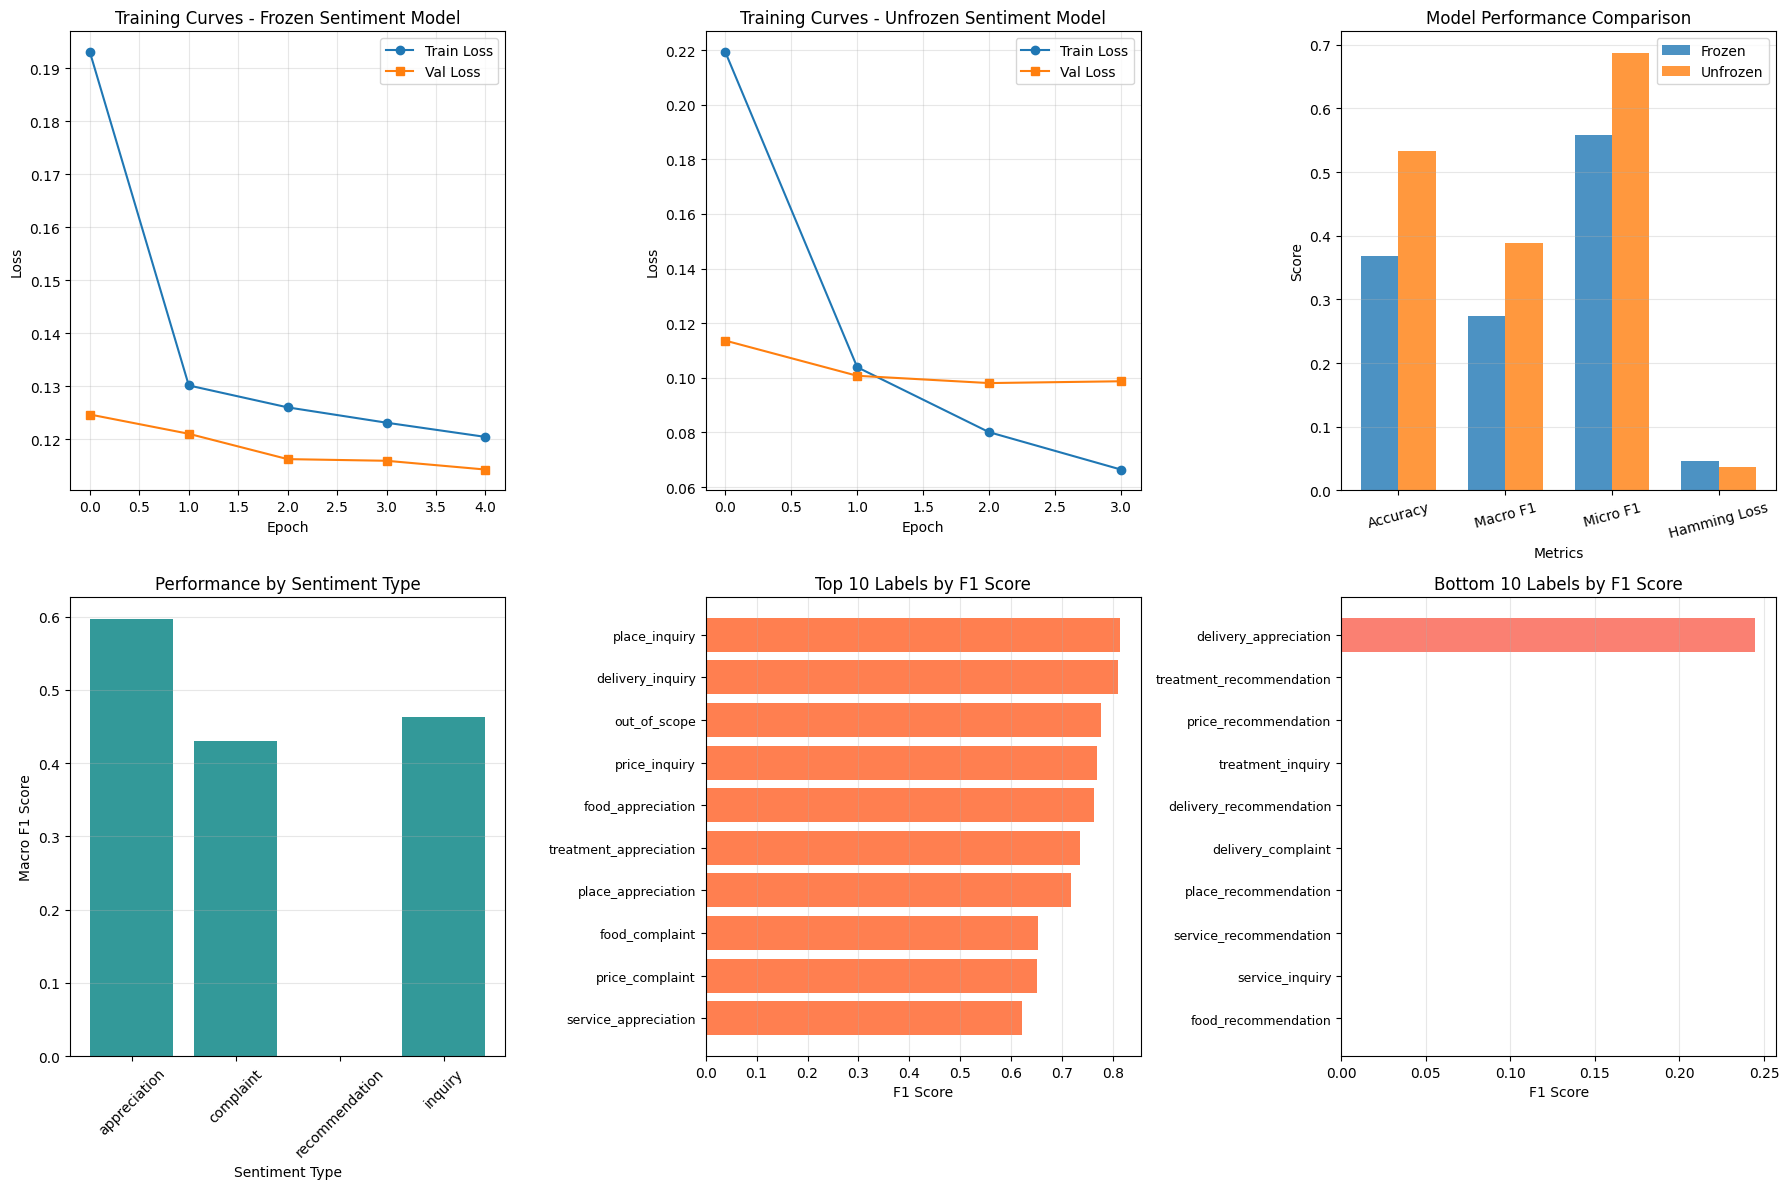

In [ ]:


# ============================================================================
# 10. DETAILED EVALUATION & COMPARISON
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': list(test_metrics_frozen.keys()),
    'Frozen Sentiment': list(test_metrics_frozen.values()),
    'Unfrozen Sentiment': list(test_metrics_unfrozen.values())
})
comparison_df['Improvement'] = comparison_df['Unfrozen Sentiment'] - comparison_df['Frozen Sentiment']
print(comparison_df.to_string(index=False))

# Per-label performance for best model
print("\n" + "="*80)
print("PER-LABEL CLASSIFICATION REPORT (UNFROZEN SENTIMENT MODEL)")
print("="*80)

print(classification_report(
    test_true,
    test_preds_binary_unfrozen,
    target_names=label_columns,
    zero_division=0
))

# Sentiment-specific analysis
print("\n" + "="*80)
print("SENTIMENT-SPECIFIC PERFORMANCE")
print("="*80)

sentiment_groups = {
    'appreciation': [i for i, col in enumerate(label_columns) if 'appreciation' in col],
    'complaint': [i for i, col in enumerate(label_columns) if 'complaint' in col],
    'recommendation': [i for i, col in enumerate(label_columns) if 'recommendation' in col],
    'inquiry': [i for i, col in enumerate(label_columns) if 'inquiry' in col]
}

for sentiment, indices in sentiment_groups.items():
    if len(indices) > 0:
        sentiment_true = test_true[:, indices]
        sentiment_pred = test_preds_binary_unfrozen[:, indices]

        f1 = f1_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        precision = precision_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        recall = recall_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)

        print(f"\n{sentiment.upper()}:")
        print(f"  Macro F1: {f1:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training curves - Frozen
axes[0, 0].plot(train_losses_frozen, label='Train Loss', marker='o')
axes[0, 0].plot(val_losses_frozen, label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Curves - Frozen Sentiment Model')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training curves - Unfrozen
axes[0, 1].plot(train_losses_unfrozen, label='Train Loss', marker='o')
axes[0, 1].plot(val_losses_unfrozen, label='Val Loss', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training Curves - Unfrozen Sentiment Model')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Metrics comparison
metrics_names = ['Accuracy', 'Macro F1', 'Micro F1', 'Hamming Loss']
metrics_frozen = [test_metrics_frozen['accuracy'], test_metrics_frozen['macro_f1'],
                  test_metrics_frozen['micro_f1'], test_metrics_frozen['hamming_loss']]
metrics_unfrozen = [test_metrics_unfrozen['accuracy'], test_metrics_unfrozen['macro_f1'],
                    test_metrics_unfrozen['micro_f1'], test_metrics_unfrozen['hamming_loss']]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 2].bar(x - width/2, metrics_frozen, width, label='Frozen', alpha=0.8)
axes[0, 2].bar(x + width/2, metrics_unfrozen, width, label='Unfrozen', alpha=0.8)
axes[0, 2].set_xlabel('Metrics')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Model Performance Comparison')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(metrics_names, rotation=15)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Sentiment type performance
sentiment_f1s = []
sentiment_names = []
for sentiment, indices in sentiment_groups.items():
    if len(indices) > 0:
        sentiment_true = test_true[:, indices]
        sentiment_pred = test_preds_binary_unfrozen[:, indices]
        f1 = f1_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        sentiment_f1s.append(f1)
        sentiment_names.append(sentiment)

axes[1, 0].bar(sentiment_names, sentiment_f1s, alpha=0.8, color='teal')
axes[1, 0].set_xlabel('Sentiment Type')
axes[1, 0].set_ylabel('Macro F1 Score')
axes[1, 0].set_title('Performance by Sentiment Type')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Per-label F1 scores
label_f1_scores = []
for i in range(len(label_columns)):
    f1 = f1_score(test_true[:, i], test_preds_binary_unfrozen[:, i], zero_division=0)
    label_f1_scores.append(f1)

top_10_indices = np.argsort(label_f1_scores)[-10:]
axes[1, 1].barh(range(10), [label_f1_scores[i] for i in top_10_indices], color='coral')
axes[1, 1].set_yticks(range(10))
axes[1, 1].set_yticklabels([label_columns[i] for i in top_10_indices], fontsize=9)
axes[1, 1].set_xlabel('F1 Score')
axes[1, 1].set_title('Top 10 Labels by F1 Score')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Bottom 10 labels
bottom_10_indices = np.argsort(label_f1_scores)[:10]
axes[1, 2].barh(range(10), [label_f1_scores[i] for i in bottom_10_indices], color='salmon')
axes[1, 2].set_yticks(range(10))
axes[1, 2].set_yticklabels([label_columns[i] for i in bottom_10_indices], fontsize=9)
axes[1, 2].set_xlabel('F1 Score')
axes[1, 2].set_title('Bottom 10 Labels by F1 Score')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------
# 1️⃣ Prepare your list of comments
# ------------------------------
comments = [
    "le serveur a un bon sourire  [APPRECIATION]",
    "On a été pour un dîner on a pris un mélange de salades comme entrée je dirais que c'était plutôt pas mal Pour les plats c'était bons des portions bien généreuse personnel très accueillant et gentil niveau propreté c'est bien je trouve juste que les prix sont un peu très élevé pour des plats pareils.",
    "هدو هما لعايشين لاسف  يزيدو للبحر سعيدة زوالي والله مايذوها",
    "والله يا نزيهة تعاوديها تخرجي برا [APPRECIATION]",
    "Je préfère payer cher chez Weld bladi que ailleurs  [APPRECIATION]",
    "Mailleur tacos franchement lbana tahdar",
    "من مليون ونص وطلع لاربعة اشخاص",
    "صحاب بولحية كامل ما يتآمنوش ما غير الرسل والصحابة",
    "هما قبل مايفتح : علاش حنا دولة ماشي كيما باقي الدول معندناش KFC هما بعد الفتح : و المقاطعة كيفاه ?",
    "J'ai commandé un kunafa J'ai pas d tout aimé Accueil 10/10 Ambiance 10/10 Service 10/10 Kunafa 4/10",
    "magnifique bon courage",
    "Excellent restaurant, viande servie de qualité. Le service est exceptionnel, les serveurs sont à l'écoute sachant se faire discret quand il faut. Je recommande ce restaurant, petit bémol concernant le parking clientèle très petit, vraiment très petit.",
    "Très bon resto turk avec tous les plats typiques. Franchement rien a dire a part parfait. Service toujours par les chefs eux meme.",
    "excellent Resto",
    "ونا بلاصة في عنابة",
    "C'est où ça",
    "200 الف نشري زوج حاجات تخرج عليا خير",
    "J’ai eu le privilège de goûter à ces Donuts, ça a été un 10/10 ! Miam  [BOUFFE]",
    "Bonsoir Mr Hicham j'espère que vous allez bien je suis une cliente fidèle de hicham cook cook and grill your restaurant is an mandatory passage when I'm on Algiers (I live in Annaba)we wanted to test yesterday the hicham cook pizza but we were disappointed unfortunately the service was too long we stayed twenty minutes waiting for someone to come pick up our orders! We wanted to add other orders it was 22h45 the waiter comes back empty-handed and tells us that he is really sorry that the cooks stopped the service pack it's closing time we were shocked we went out and we were still hungry! we paid the delay caused by your team and that's not worthy of your name MR pack I know very well that you never tolerate such a thing in your restaurants I wanted to let you know to take appropriate measures to this kind of situation Thank you",
    "C’est a centre ville en face la wilaya",
    "استناوني نلقى خدمة تم ونجي",
    "شحال توصيل للشراڨة .",
    "Très classe, je le recommande",
    "وين هذي ليوم نكون عندك"
]

# ------------------------------
# 2️⃣ Tokenize
# ------------------------------
encoding = tokenizer(
    comments,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'
).to(device)

# ------------------------------
# 3️⃣ Run inference on BOTH models
# ------------------------------
THRESHOLD = 0.5

def predict_multilabel(model, encoding, threshold=THRESHOLD):
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=encoding['input_ids'], attention_mask=encoding['attention_mask'])
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).int()
    return probs.cpu().numpy(), preds.cpu().numpy()

# Model from first notebook
probs_frozen, preds_frozen = predict_multilabel(model_frozen, encoding)

# Model from second notebook (misleading metrics)
probs_second, preds_second = predict_multilabel(model_unfrozen, encoding)

# ------------------------------
# 4️⃣ Display results
# ------------------------------
import pandas as pd

def map_predictions_to_labels(predictions, label_columns):
    predicted_labels = []
    for i, pred in enumerate(predictions):
        if pred == 1:
            predicted_labels.append(label_columns[i])
    return predicted_labels

df_results = pd.DataFrame({
    'comment': comments,
    'pred_frozen': [map_predictions_to_labels(p, label_columns) for p in preds_frozen],
    'pred_unfrozen': [map_predictions_to_labels(p, label_columns) for p in preds_second]
})

df_results.head(20)  # display first 20 comments

,comment,pred_frozen,pred_unfrozen
0,le serveur a un bon sourire [APPRECIATION],"[food_appreciation, place_appreciation]",[treatment_appreciation]
1,On a été pour un dîner on a pris un mélange de...,[food_complaint],"[food_appreciation, service_appreciation, plac..."
2,هدو هما لعايشين لاسف يزيدو للبحر سعيدة زوالي ...,[price_complaint],[out_of_scope]
3,والله يا نزيهة تعاوديها تخرجي برا [APPRECIATION],[out_of_scope],[out_of_scope]
4,Je préfère payer cher chez Weld bladi que aill...,[price_complaint],[price_complaint]
5,Mailleur tacos franchement lbana tahdar,[],[]
6,من مليون ونص وطلع لاربعة اشخاص,[price_complaint],[price_complaint]
7,صحاب بولحية كامل ما يتآمنوش ما غير الرسل والصحابة,[out_of_scope],[out_of_scope]
8,هما قبل مايفتح : علاش حنا دولة ماشي كيما باقي ...,[],[out_of_scope]
9,J'ai commandé un kunafa J'ai pas d tout aimé A...,[],"[food_appreciation, service_appreciation, plac..."
